# Lab 2 — Precision Recruiting with Recommender Systems

**Mission:** Limited recruiter time means we cannot visit every school. Build a transparent system that answers:

1. **WHERE should we focus?** Rank schools by downstream value and operational feasibility.
2. **WHAT should we try there?** Recommend an engagement using patterns from behaviorally similar schools.

You will deliberately begin with the wrong objective, watch the ranking change, and then infer a promising action Jefferson High has never tried.

**Estimated time:** 75 minutes (Lab A: 30; Lab B: 45)

> **Completed instructor version.** Exercise values and functions are filled in, self-checks are executed, and explanations follow each solution. 

> **Use your coding assistant as a teammate.** Give it the current cell, the self-check output, and the goal. Ask it to explain the smallest useful change rather than rewriting the notebook.

Suggested prompt:

> I am working in a classroom Jupyter notebook. Explain what this self-check is testing, then suggest the smallest edit to the marked variables. Do not change the data or the test.

In [1]:
from IPython.display import display, Markdown

def check(name, condition, hint=""):
    try:
        passed = bool(condition)
    except Exception as exc:
        passed = False
        hint = f"{hint} ({type(exc).__name__}: {exc})"
    icon = "✅" if passed else "❌"
    print(f"{icon} {name}")
    if not passed and hint:
        print(f"   Hint: {hint}")
    return passed

def mission_header(text):
    display(Markdown(f"> **Mission checkpoint:** {text}"))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 30)
pd.options.display.float_format = "{:,.3f}".format

Matplotlib is building the font cache; this may take a moment.


## Synthetic data with an intentional story

All people, schools, outcomes, and policies in this notebook are fictional classroom data. Protected characteristics are not used.

In [3]:
names = [
    "Lincoln High", "Jefferson High", "Washington High", "Roosevelt High",
    "North County Tech", "Lakeside Academy", "Madison High", "Franklin High",
    "Central High", "Riverside High", "Eastview High", "Westfield High",
    "Pine Ridge High", "Oak Valley High", "Summit High", "Cedar Grove High",
    "Parkview High", "Liberty High", "Monroe High", "Adams High"
]

schools = pd.DataFrame({
    "school_name": names,
    "recruiter_hours": rng.integers(55, 125, len(names)),
    "appointments": rng.integers(35, 105, len(names)),
    "access_score": rng.uniform(.45, .98, len(names)),
    "distance_miles": rng.integers(4, 48, len(names)),
    "data_quality": rng.uniform(.68, .99, len(names)),
})

# Build realistic downstream counts, then overwrite anchor schools for classroom reveals.
schools["qualified"] = (schools["appointments"] * rng.uniform(.35, .68, len(names))).round().astype(int)
schools["contracts"] = (schools["qualified"] * rng.uniform(.32, .65, len(names))).round().astype(int)

anchors = {
    "Lincoln High":      [100, 140, 35, 14, .90, 8,  .95],
    "Jefferson High":    [100,  80, 40, 24, .85, 12, .94],
    "Washington High":   [100,  60, 36, 25, .72, 18, .91],
    "Roosevelt High":    [ 90,  75, 32, 18, .95, 6,  .88],
    "North County Tech": [ 82,  67, 39, 23, .80, 22, .93],
    "Summit High":       [ 76,  70, 42, 28, .86, 16, .55],  # strong, unreliable
    "Liberty High":      [ 88,  73, 39, 24, .82, 44, .96],  # strong, too far
}
cols = ["recruiter_hours", "appointments", "qualified", "contracts",
        "access_score", "distance_miles", "data_quality"]
for name, values in anchors.items():
    schools.loc[schools["school_name"].eq(name), cols] = values

schools.head(8)

,school_name,recruiter_hours,appointments,access_score,distance_miles,data_quality,qualified,contracts
0,Lincoln High,100,140,0.900,8,0.950,35,14
1,Jefferson High,100,80,0.850,12,0.940,40,24
2,Washington High,100,60,0.720,18,0.910,36,25
3,Roosevelt High,90,75,0.950,6,0.880,32,18
4,North County Tech,82,67,0.800,22,0.930,39,23
5,Lakeside Academy,115,80,0.553,34,0.922,35,18
6,Madison High,61,63,0.697,8,0.822,28,12
7,Franklin High,103,92,0.473,17,0.856,52,18


# Lab A — WHERE should we focus?

## A1. Rank by activity

If appointments are the goal, Lincoln appears to win. Pause before running the next cell: is appointment volume the outcome USARD actually wants to optimize?

In [4]:
appointment_ranking = schools.nlargest(5, "appointments")[["school_name", "appointments", "qualified", "contracts"]]
appointment_ranking

,school_name,appointments,qualified,contracts
0,Lincoln High,140,35,14
16,Parkview High,95,56,26
7,Franklin High,92,52,18
1,Jefferson High,80,40,24
5,Lakeside Academy,80,35,18


## A2. Look downstream

Complete the four marked column choices. The cell runs even before it is correct; the checks tell you what to fix.

In [5]:
QUALIFIED_NUMERATOR = "qualified"    # downstream qualified applicants
QUALIFIED_DENOMINATOR = "appointments" # appointment opportunities
EFFICIENCY_NUMERATOR = "contracts"     # downstream outcome
EFFICIENCY_DENOMINATOR = "recruiter_hours"

schools["qualified_rate"] = (
    schools[QUALIFIED_NUMERATOR] / schools[QUALIFIED_DENOMINATOR]
)
schools["contracts_per_hour"] = (
    schools[EFFICIENCY_NUMERATOR] / schools[EFFICIENCY_DENOMINATOR]
)

schools.nlargest(5, "contracts_per_hour")[[
    "school_name", "appointments", "qualified", "contracts", "contracts_per_hour"
]]

,school_name,appointments,qualified,contracts,contracts_per_hour
9,Riverside High,66,40,25,0.410
14,Summit High,70,42,28,0.368
19,Adams High,79,41,25,0.291
16,Parkview High,95,56,26,0.289
4,North County Tech,67,39,23,0.280


### Solution explanation — downstream measures

`qualified ÷ appointments` measures how often appointments reach qualification. `contracts ÷ recruiter_hours` measures downstream success per constrained resource. These choices deliberately move the objective away from raw activity volume.

In [6]:
check("Qualification rate uses qualified ÷ appointments",
      QUALIFIED_NUMERATOR == "qualified" and QUALIFIED_DENOMINATOR == "appointments",
      "The numerator is the number that made it through qualification.")
check("Efficiency uses contracts ÷ recruiter hours",
      EFFICIENCY_NUMERATOR == "contracts" and EFFICIENCY_DENOMINATOR == "recruiter_hours",
      "We care about downstream success per constrained hour.")
check("Lincoln's appointment volume does not make it the efficiency leader",
      schools.nlargest(1, "appointments").iloc[0]["school_name"] != schools.nlargest(1, "contracts_per_hour").iloc[0]["school_name"],
      "Fix the efficiency numerator first.")

✅ Qualification rate uses qualified ÷ appointments
✅ Efficiency uses contracts ÷ recruiter hours
✅ Lincoln's appointment volume does not make it the efficiency leader


True

## A3. Define an explainable opportunity score

The mission owner chose:

- 60% downstream efficiency
- 25% qualification rate
- 15% school access

Edit the three weights. The algorithm cannot decide the objective for us.

In [7]:
scaler = MinMaxScaler()
features = ["contracts_per_hour", "qualified_rate", "access_score"]
schools[["success_norm", "qualified_norm", "access_norm"]] = scaler.fit_transform(schools[features])

SUCCESS_WEIGHT = .60
QUALIFIED_WEIGHT = .25
ACCESS_WEIGHT = .15

schools["opportunity_score"] = (
    SUCCESS_WEIGHT * schools["success_norm"]
    + QUALIFIED_WEIGHT * schools["qualified_norm"]
    + ACCESS_WEIGHT * schools["access_norm"]
)

### Solution explanation — mission weights

The weights encode a human-defined operational objective: 60% downstream efficiency, 25% qualification rate, and 15% access. Normalization puts unlike measures on a common 0–1 scale before the weighted sum.

In [8]:
check("Weights sum to 1", np.isclose(SUCCESS_WEIGHT + QUALIFIED_WEIGHT + ACCESS_WEIGHT, 1.0))
check("Weights match the mission objective",
      np.allclose([SUCCESS_WEIGHT, QUALIFIED_WEIGHT, ACCESS_WEIGHT], [.60, .25, .15]),
      "Translate 60%, 25%, and 15% into decimals.")

✅ Weights sum to 1
✅ Weights match the mission objective


True

## A4. Filter infeasible or unreliable options

Scores do not override operations. Set the thresholds to **30 miles** and **0.70 data quality**.

In [9]:
MAX_DISTANCE = 30
MIN_DATA_QUALITY = 0.70

eligible = schools.loc[
    schools["distance_miles"].le(MAX_DISTANCE)
    & schools["data_quality"].ge(MIN_DATA_QUALITY)
].copy()

excluded = schools.loc[~schools.index.isin(eligible.index), [
    "school_name", "distance_miles", "data_quality", "opportunity_score"
]].sort_values("opportunity_score", ascending=False)
display(Markdown("**Excluded options**"))
display(excluded)

**Excluded options**

,school_name,distance_miles,data_quality,opportunity_score
9,Riverside High,40,0.716,0.951
14,Summit High,16,0.550,0.888
17,Liberty High,44,0.960,0.661
8,Central High,37,0.723,0.449
11,Westfield High,39,0.826,0.372
12,Pine Ridge High,41,0.855,0.337
5,Lakeside Academy,34,0.922,0.306
18,Monroe High,32,0.690,0.139


### Solution explanation — operational constraints

Filtering happens before Top-K selection. Summit is removed because its history is unreliable; Liberty is removed because travel exceeds the current constraint. A strong score cannot override feasibility or evidence quality.

In [10]:
check("Distance threshold is operationally correct", MAX_DISTANCE == 30)
check("Data-quality threshold is operationally correct", np.isclose(MIN_DATA_QUALITY, .70))
check("Summit is excluded for weak data", "Summit High" not in set(eligible["school_name"]))
check("Liberty is excluded for travel", "Liberty High" not in set(eligible["school_name"]))

✅ Distance threshold is operationally correct
✅ Data-quality threshold is operationally correct
✅ Summit is excluded for weak data
✅ Liberty is excluded for travel


True

## A5. Return Top K

Set `K = 5`, then explain why this is a recommendation—not an automated decision.

In [11]:
K = 5
top_schools = eligible.nlargest(K, "opportunity_score").copy()
top_schools[["school_name", "opportunity_score", "contracts_per_hour", "qualified_rate", "access_score"]]

,school_name,opportunity_score,contracts_per_hour,qualified_rate,access_score
4,North County Tech,0.702,0.280,0.582,0.800
10,Eastview High,0.682,0.264,0.576,0.845
19,Adams High,0.678,0.291,0.519,0.805
2,Washington High,0.636,0.250,0.600,0.720
16,Parkview High,0.636,0.289,0.589,0.519


### Solution explanation — Top K

`K = 5` returns a manageable shortlist, not an automated assignment. The displayed component measures let a human see why each school ranked highly.

✅ Top K returns five schools


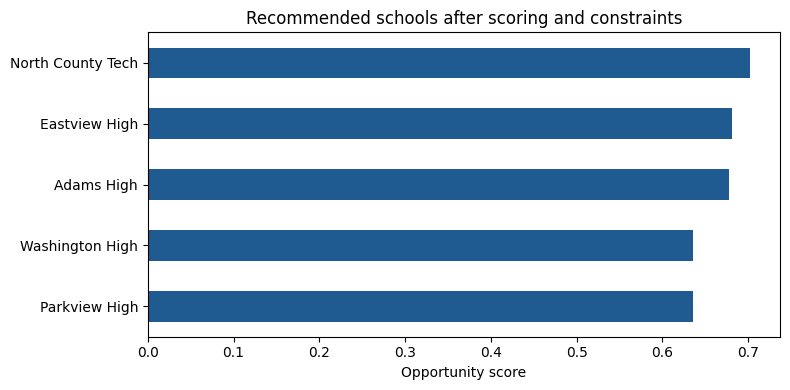

In [12]:
check("Top K returns five schools", K == 5 and len(top_schools) == 5)

ax = top_schools.sort_values("opportunity_score").plot.barh(
    x="school_name", y="opportunity_score", legend=False, color="#1f5a91", figsize=(8, 4)
)
ax.set(title="Recommended schools after scoring and constraints", xlabel="Opportunity score", ylabel="")
plt.tight_layout()
plt.show()

> **Aha:** A recommender can produce a perfectly correct ranking for the wrong objective. There is no universal “best” school—only a ranking tied to an objective, evidence, and constraints.

# Lab B — WHAT should we do there?

Jefferson High is a selected decision context. We now treat schools like “users,” engagement actions like “items,” and historical contracts per recruiter-hour like a “rating.”

In [13]:
actions = [
    "Cyber Careers Event", "STEM Careers Presentation", "Mechanical Careers Demo",
    "Healthcare Careers Session", "Education Benefits Session", "General Recruiting Table"
]

effectiveness_map = {
    "Jefferson High":    [.65, .60, np.nan, .10, .30, .25],
    "Lincoln High":      [.55, .60, .80, .15, .25, .30],
    "Washington High":   [.70, .65, .75, .10, .30, .25],
    "North County Tech": [.60, .55, .70, .20, .35, .30],
    "Roosevelt High":    [.15, .20, .25, .75, .50, .45],
    "Lakeside Academy":  [.30, .25, .35, .65, .45, .40],
    "Madison High":      [.45, .50, .60, .20, .35, .30],
    "Franklin High":     [.25, .30, .40, .55, .45, .40],
}

rows = []
for school, values in effectiveness_map.items():
    for action, value in zip(actions, values):
        if pd.isna(value):
            continue
        hours = 20
        contracts = int(round(value * hours))
        rows.append({
            "school_name": school, "action": action, "recruiter_hours": hours,
            "appointments": max(contracts * 3, contracts + 2),
            "qualified": max(contracts * 2, contracts + 1), "contracts": contracts,
        })

engagements = pd.DataFrame(rows)
engagements["effectiveness"] = engagements["contracts"] / engagements["recruiter_hours"]
engagements.sample(8, random_state=SEED)

,school_name,action,recruiter_hours,appointments,qualified,contracts,effectiveness
27,Roosevelt High,Education Benefits Session,20,30,20,10,0.500
39,Madison High,Education Benefits Session,20,21,14,7,0.350
26,Roosevelt High,Healthcare Careers Session,20,45,30,15,0.750
43,Franklin High,Mechanical Careers Demo,20,24,16,8,0.400
24,Roosevelt High,STEM Careers Presentation,20,12,8,4,0.200
36,Madison High,STEM Careers Presentation,20,30,20,10,0.500
12,Washington High,STEM Careers Presentation,20,39,26,13,0.650
19,North County Tech,Mechanical Careers Demo,20,42,28,14,0.700


## B1. Build the school × action matrix

What does the blank cell for Jefferson + Mechanical mean? It means **unobserved**, not failed.

In [14]:
school_action = engagements.pivot_table(
    index="school_name", columns="action", values="effectiveness", aggfunc="mean"
).reindex(columns=actions)
school_action.style.format("{:.2f}", na_rep="—").background_gradient(cmap="Blues", axis=None)

action,Cyber Careers Event,STEM Careers Presentation,Mechanical Careers Demo,Healthcare Careers Session,Education Benefits Session,General Recruiting Table
school_name,,,,,,
Franklin High,0.25,0.30,0.40,0.55,0.45,0.40
Jefferson High,0.65,0.60,—,0.10,0.30,0.25
Lakeside Academy,0.30,0.25,0.35,0.65,0.45,0.40
Lincoln High,0.55,0.60,0.80,0.15,0.25,0.30
Madison High,0.45,0.50,0.60,0.20,0.35,0.30
North County Tech,0.60,0.55,0.70,0.20,0.35,0.30
Roosevelt High,0.15,0.20,0.25,0.75,0.50,0.45
Washington High,0.70,0.65,0.75,0.10,0.30,0.25


In [15]:
TARGET_SCHOOL = "Jefferson High"
check("Jefferson has no Mechanical history", pd.isna(school_action.loc[TARGET_SCHOOL, "Mechanical Careers Demo"]))
check("Missing does not become zero", not (school_action.fillna(-1).loc[TARGET_SCHOOL, "Mechanical Careers Demo"] == 0))

✅ Jefferson has no Mechanical history
✅ Missing does not become zero


True

## B2. Find behaviorally similar schools

Cosine similarity should use only actions observed at both schools. Require at least **two** overlapping actions.

In [16]:
MIN_OVERLAP = 2

def cosine_on_overlap(a, b, min_overlap=MIN_OVERLAP):
    mask = a.notna() & b.notna()
    if mask.sum() < min_overlap:
        return np.nan
    x = a[mask].to_numpy(dtype=float)
    y = b[mask].to_numpy(dtype=float)
    denominator = np.linalg.norm(x) * np.linalg.norm(y)
    return np.nan if denominator == 0 else float(np.dot(x, y) / denominator)

target_vector = school_action.loc[TARGET_SCHOOL]
similarities = pd.Series({
    school: cosine_on_overlap(target_vector, school_action.loc[school])
    for school in school_action.index if school != TARGET_SCHOOL
}, name="similarity").dropna().sort_values(ascending=False)

similarities.to_frame()

,similarity
Washington High,1.000
Lincoln High,0.992
North County Tech,0.989
Madison High,0.971
Franklin High,0.720
Lakeside Academy,0.685
Roosevelt High,0.550


### Solution explanation — overlap-aware similarity

Cosine similarity is calculated only on actions observed at both schools. Requiring two overlaps avoids declaring two schools similar because of a single shared event result.

In [17]:
check("Similarity requires at least two overlaps", MIN_OVERLAP == 2,
      "One shared action is too little evidence for a stable similarity.")
check("Washington is Jefferson's closest behavioral neighbor", similarities.index[0] == "Washington High")

✅ Similarity requires at least two overlaps
✅ Washington is Jefferson's closest behavioral neighbor


True

## B3. Predict an untried action

Turn on similarity weighting. A close neighbor should contribute more than a weak neighbor. To avoid diluting the signal with every weakly related school, use the three nearest behavioral neighbors.

In [18]:
USE_SIMILARITY_WEIGHTS = True
NEIGHBOR_COUNT = 3

def predict_action(action, matrix=school_action, sims=similarities):
    evidence = []
    for school, similarity in sims.head(NEIGHBOR_COUNT).items():
        value = matrix.loc[school, action]
        if pd.notna(value) and similarity > 0:
            evidence.append((school, float(similarity), float(value)))
    if not evidence:
        return np.nan
    if USE_SIMILARITY_WEIGHTS:
        numerator = sum(sim * value for _, sim, value in evidence)
        denominator = sum(sim for _, sim, _ in evidence)
        return numerator / denominator
    return np.mean([value for _, _, value in evidence])

mechanical_prediction = predict_action("Mechanical Careers Demo")
print(f"Predicted contracts per recruiter-hour: {mechanical_prediction:.3f}")

Predicted contracts per recruiter-hour: 0.750


### Solution explanation — similarity-weighted prediction

The three nearest behavioral neighbors contribute to the missing Mechanical score. Each neighbor’s outcome is weighted by similarity, making stronger analogues more influential. The result remains labeled `predicted` so it is not confused with direct Jefferson evidence.

In [19]:
check("Prediction uses similarity weighting", USE_SIMILARITY_WEIGHTS)
check("Mechanical is predicted to be promising", mechanical_prediction > .60,
      "Verify the similarity-weighted average and the target's missing cell.")

✅ Prediction uses similarity weighting
✅ Mechanical is predicted to be promising


True

## B4. Rank observed and predicted actions together

Keep provenance visible. A predicted score is not the same kind of evidence as an observed score.

In [20]:
recommendations = school_action.loc[TARGET_SCHOOL].copy()
evidence_type = pd.Series("observed", index=recommendations.index)

for action in recommendations.index[recommendations.isna()]:
    recommendations[action] = predict_action(action)
    evidence_type[action] = "predicted"

action_ranking = pd.DataFrame({
    "score": recommendations,
    "evidence": evidence_type,
}).sort_values("score", ascending=False)

action_ranking.head(3)

,score,evidence
action,,
Mechanical Careers Demo,0.750,predicted
Cyber Careers Event,0.650,observed
STEM Careers Presentation,0.600,observed


In [21]:
check("Mechanical is the top recommendation", action_ranking.index[0] == "Mechanical Careers Demo")
check("Mechanical is labeled predicted", action_ranking.loc["Mechanical Careers Demo", "evidence"] == "predicted")
check("Observed actions remain labeled observed", (action_ranking.drop("Mechanical Careers Demo")["evidence"] == "observed").all())

✅ Mechanical is the top recommendation
✅ Mechanical is labeled predicted
✅ Observed actions remain labeled observed


True

## Optional challenge — Content and hybrid evidence

Collaborative evidence asks, “What worked at schools that behaved like Jefferson?” Content evidence asks, “What fits Jefferson’s aggregate program profile?” Combine them only if you can explain the weights.

In [22]:
dimensions = ["cyber", "engineering", "mechanical", "healthcare", "education"]
jefferson_profile = np.array([[.90, .80, .65, .15, .40]])
action_profiles = pd.DataFrame([
    [.95, .75, .20, .05, .15], [.70, .95, .35, .05, .20], [.10, .60, 1.0, .00, .20],
    [.05, .10, .05, 1.0, .15], [.10, .20, .10, .15, 1.0], [.35, .35, .35, .35, .35],
], index=actions, columns=dimensions)

content_scores = pd.Series(
    cosine_similarity(jefferson_profile, action_profiles.values)[0], index=actions, name="content_score"
)
collab_norm = (recommendations - recommendations.min()) / (recommendations.max() - recommendations.min())
hybrid = pd.DataFrame({"collaborative": collab_norm, "content": content_scores})
hybrid["hybrid"] = .60 * hybrid["collaborative"] + .40 * hybrid["content"]
hybrid.sort_values("hybrid", ascending=False).head(3)

,collaborative,content,hybrid
Mechanical Careers Demo,1.000,0.764,0.905
Cyber Careers Event,0.846,0.932,0.880
STEM Careers Presentation,0.769,0.953,0.843


## Red-team pause

Discuss before deployment:

- Are we learning what works—or what recruiters historically chose to try?
- How old can evidence be before it becomes stale?
- Should a prediction based on two overlapping actions receive the same confidence as one based on five?
- Which fields must never be used as ranking features?

**Transition:** We now have a WHERE and a WHAT. The recruiter still needs authoritative information before acting. That is the job of RAG.